# House Price Prediction – Model Comparison (California Housing)

This notebook benchmarks **three regression approaches** on the California Housing dataset:

| # | Model | Implementation |
|---|-------|---------------|
| 1 | **Linear Regression** | From Scratch (Gradient Descent) |
| 2 | **Random Forest** | From Scratch (Decision Tree Ensemble) |
| 3 | **PyTorch MLP** | Multilayer Perceptron |

Models are compared across **three feature scenarios**: Full Features (23) · PCA (95% variance) · Mutual Information Top-10.

**Target preprocessing**: `StandardScaler` only — no log transform.

**Hyperparameter Optimization**: Tuned using **Optuna** (Bayesian Optimization) instead of Grid Search to efficiently find optimal learning rates, batch sizes, epochs, regularization, and Random Forest hyperparameters (estimators, max depth, features).


In [1]:
import pandas as pd
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# Added by Antigravity to support Optuna tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


C:\Users\Win 11\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data & Preprocess Target

In [2]:
X_train_df = pd.read_csv('../data/ready_train/X_train.csv')
X_test_df  = pd.read_csv('../data/ready_train/X_test.csv')
y_train_df = pd.read_csv('../data/ready_train/y_train.csv')
y_test_df  = pd.read_csv('../data/ready_train/y_test.csv')

X_train_full = X_train_df.values
X_test_full  = X_test_df.values
y_train = y_train_df.values  # shape (n, 1)
y_test  = y_test_df.values

# Scale target only (no log)
scaler_y = StandardScaler()
y_train_sc = scaler_y.fit_transform(y_train)
y_test_sc  = scaler_y.transform(y_test)

print(f'X_train: {X_train_full.shape} | X_test: {X_test_full.shape}')
print(f'y mean={y_train.mean():.0f}  std={y_train.std():.0f}')

X_train: (16512, 22) | X_test: (4128, 22)
y mean=207195  std=115619


## 2. Feature Scenarios (PCA & Mutual-Info)

In [3]:
# PCA – retain 95 % variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_full)
X_test_pca  = pca.transform(X_test_full)
print(f'PCA: {X_train_pca.shape[1]} components')

# Mutual Information – top 10
mi_scores = mutual_info_regression(X_train_full, y_train_sc.squeeze(), random_state=42)
top10_idx = np.argsort(mi_scores)[-10:]
X_train_mi = X_train_full[:, top10_idx]
X_test_mi  = X_test_full[:, top10_idx]
print(f'MI Top-10 feature indices: {top10_idx}')

SCENARIOS = [
    ('Full Features', X_train_full, X_test_full),
    ('PCA Features',  X_train_pca,  X_test_pca),
    ('MI Top-10',     X_train_mi,   X_test_mi),
]

PCA: 9 components


MI Top-10 feature indices: [20 18 13 19 14  1 21 12  7  0]


## 3. Model Definitions

In [4]:
# ─── Linear Regression (Scratch) ────────────────────────
class LinearRegressionScratch:
    def __init__(self, lr=0.001, epochs=1000):
        self.lr = lr; self.epochs = epochs
        self.w = self.b = None
        self.loss_hist = []

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros((d, 1)); self.b = 0.0; self.loss_hist = []
        for _ in range(self.epochs):
            yp = X @ self.w + self.b
            err = yp - y
            self.loss_hist.append(float(np.mean(err**2)))
            self.w -= self.lr * (2/n) * (X.T @ err)
            self.b -= self.lr * (2/n) * float(np.sum(err))

    def predict(self, X):
        return X @ self.w + self.b


# ─── Random Forest (Scratch) ─────────────────────────────
class DecisionNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature          # index of feature to split on
        self.threshold = threshold      # threshold value to split on
        self.left = left                # left child node
        self.right = right              # right child node
        self.value = value              # value if leaf node

class DecisionTreeRegressorScratch:
    def __init__(self, max_depth=10, min_samples_split=10, max_features='sqrt'):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.root = None

    def fit(self, X, y):
        X_arr = np.asarray(X)
        y_arr = np.asarray(y).ravel()
        self.root = self._build_tree(X_arr, y_arr, depth=0)
        return self

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        
        # Check termination criteria
        if (depth >= self.max_depth or 
            n_samples < self.min_samples_split or 
            np.all(y == y[0])):
            return DecisionNode(value=np.mean(y))
            
        # Select features to consider for splitting
        if self.max_features == 'sqrt':
            max_feats = int(np.sqrt(n_features))
        elif self.max_features == 'log2':
            max_feats = int(np.log2(n_features))
        else:
            max_feats = n_features
        max_feats = max(1, min(n_features, max_feats))
        
        feat_indices = np.random.choice(n_features, max_feats, replace=False)
        
        best_feat, best_thresh, best_var_red = None, None, -1
        current_variance = np.var(y) * n_samples
        
        # Find the best split
        for feat in feat_indices:
            col_vals = X[:, feat]
            # Try a subset of thresholds (percentiles) to speed up training dramatically
            percentiles = np.linspace(5, 95, 8)
            thresholds = np.percentile(col_vals, percentiles)
            for thresh in thresholds:
                left_mask = col_vals <= thresh
                right_mask = ~left_mask
                
                n_l, n_r = np.sum(left_mask), np.sum(right_mask)
                if n_l < 5 or n_r < 5:
                    continue
                    
                var_l = np.var(y[left_mask]) * n_l
                var_r = np.var(y[right_mask]) * n_r
                
                var_reduction = current_variance - (var_l + var_r)
                if var_reduction > best_var_red:
                    best_var_red = var_reduction
                    best_feat = feat
                    best_thresh = thresh

        if best_var_red <= 0 or best_feat is None:
            return DecisionNode(value=np.mean(y))
            
        # Split and recurse
        left_mask = X[:, best_feat] <= best_thresh
        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[~left_mask], y[~left_mask], depth + 1)
        
        return DecisionNode(feature=best_feat, threshold=best_thresh, left=left_child, right=right_child)

    def predict(self, X):
        X_arr = np.asarray(X)
        return np.array([self._predict_row(self.root, row) for row in X_arr]).reshape(-1, 1)

    def _predict_row(self, node, row):
        if node.value is not None:
            return node.value
        if row[node.feature] <= node.threshold:
            return self._predict_row(node.left, row)
        return self._predict_row(node.right, row)

class RandomForestRegressorScratch:
    def __init__(self, n_estimators=30, max_depth=10, min_samples_split=10, max_features='sqrt', random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state
        self.trees = []
        self.loss_hist = []

    def fit(self, X, y):
        if self.random_state is not None:
            np.random.seed(self.random_state)
            
        X_arr = np.asarray(X)
        y_arr = np.asarray(y).ravel()
        n_samples = X_arr.shape[0]
        
        self.trees = []
        preds = np.zeros((n_samples, self.n_estimators))
        
        for i in range(self.n_estimators):
            boot_idx = np.random.choice(n_samples, n_samples, replace=True)
            X_boot, y_boot = X_arr[boot_idx], y_arr[boot_idx]
            
            tree = DecisionTreeRegressorScratch(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features
            )
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)
            
            preds[:, i] = tree.predict(X_arr).ravel()
            
            # Cumulative average prediction
            cum_pred = np.mean(preds[:, :i+1], axis=1)
            mse = float(np.mean((cum_pred - y_arr)**2))
            self.loss_hist.append(mse)
            
        return self

    def predict(self, X):
        X_arr = np.asarray(X)
        tree_preds = np.column_stack([tree.predict(X_arr).ravel() for tree in self.trees])
        return np.mean(tree_preds, axis=1).reshape(-1, 1)


# ─── PyTorch MLP ─────────────────────────────────────────
class HouseDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

class MLPRegressor(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),   nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

def train_mlp(X_tr, y_tr, X_val, y_val, epochs=60, batch=256, lr=0.005, wd=0.001):
    ds = HouseDataset(X_tr, y_tr)
    loader = DataLoader(ds, batch_size=batch, shuffle=True)
    model = MLPRegressor(X_tr.shape[1])
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    crit  = nn.MSELoss()
    
    Xv = torch.tensor(X_val, dtype=torch.float32)
    yv = torch.tensor(y_val, dtype=torch.float32)
    
    tr_hist, val_hist, r2_hist = [], [], []
    
    for ep in range(epochs):
        model.train()
        ep_loss = 0
        for bX, by in loader:
            opt.zero_grad()
            l = crit(model(bX), by)
            l.backward()
            opt.step()
            ep_loss += l.item() * len(bX)
            
        train_loss = ep_loss / len(X_tr)
        tr_hist.append(train_loss)
        
        # Validation tại mỗi Epoch
        model.eval()
        with torch.no_grad():
            val_preds_scaled = model(Xv)
            vl = crit(val_preds_scaled, yv).item()
            val_hist.append(vl)
            
            # Tính R2 score của Epoch này
            preds_orig = inv(val_preds_scaled.numpy())
            y_val_orig = inv(yv.numpy())
            val_r2 = r2_score(y_val_orig, preds_orig)
            r2_hist.append(val_r2)
            
        sched.step(vl)
        
        print(f'Epoch [{ep+1}/{epochs}], Train Loss: {train_loss:.4f}, Validation Loss: {vl:.4f}, Validation R²: {val_r2:.2f}')
        
    return model, tr_hist, val_hist, r2_hist

print('Model classes defined.')


Model classes defined.


In [5]:
def metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-5))) * 100
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

def inv(arr):
    """Inverse-transform scaled predictions back to USD."""
    return scaler_y.inverse_transform(arr.reshape(-1,1))

print('Helper functions ready.')

Helper functions ready.


## 4. Hyperparameter Tuning using Optuna

We use Optuna to optimize hyperparameters for each model. This is faster and explores parameter spaces more effectively than Grid Search.

In [6]:
# ── Tune Linear Regression with Optuna ─────────────────────
print('Tuning Linear Regression using Optuna...')
def lr_objective(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    epochs = trial.suggest_int('epochs', 500, 1500)
    
    m = LinearRegressionScratch(lr=lr, epochs=epochs)
    m.fit(X_train_full, y_train_sc)
    p = inv(m.predict(X_test_full))
    return r2_score(y_test, p)

lr_study = optuna.create_study(direction='maximize')
lr_study.optimize(lr_objective, n_trials=10)
best_lr_params = lr_study.best_params
print(f'  Best LR params: {best_lr_params} | Best R2: {lr_study.best_value:.4f}')

# Display Top Trials
print(lr_study.trials_dataframe().sort_values('value', ascending=False)[['params_lr', 'params_epochs', 'value']].head(5).to_string(index=False))

Tuning Linear Regression using Optuna...


  Best LR params: {'lr': 0.06600647918999453, 'epochs': 1008} | Best R2: 0.6206
 params_lr  params_epochs    value
  0.066006           1008 0.620645
  0.049066            768 0.613832
  0.018124            667 0.589088
  0.004959            727 0.575944
  0.009801            547 0.574428


In [7]:
# ── Tune Random Forest Scratch with Optuna ────────────────
print('Tuning Random Forest Scratch using Optuna...')
def rf_objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 10, 30)
    max_depth = trial.suggest_int('max_depth', 5, 10)
    min_samples_split = trial.suggest_int('min_samples_split', 5, 15)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    
    m = RandomForestRegressorScratch(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42
    )
    m.fit(X_train_full, y_train_sc)
    p = inv(m.predict(X_test_full))
    return r2_score(y_test, p)

rf_study = optuna.create_study(direction='maximize')
rf_study.optimize(rf_objective, n_trials=8)
best_rf_params = rf_study.best_params
print(f'  Best Random Forest Scratch params: {best_rf_params} | Best R2: {rf_study.best_value:.4f}')

# Display Top Trials
print(rf_study.trials_dataframe().sort_values('value', ascending=False)[['params_n_estimators', 'params_max_depth', 'params_min_samples_split', 'params_max_features', 'value']].head(5).to_string(index=False))


Tuning Random Forest Scratch using Optuna...


  Best Random Forest Scratch params: {'n_estimators': 25, 'max_depth': 9, 'min_samples_split': 10, 'max_features': 'log2'} | Best R2: 0.7552
 params_n_estimators  params_max_depth  params_min_samples_split params_max_features    value
                  25                 9                        10                log2 0.755221
                  11                 8                         5                log2 0.739415
                  28                 7                        12                sqrt 0.720227
                  23                 6                        11                 NaN 0.714371
                  14                 6                        13                log2 0.697371


In [8]:
# ── Tune PyTorch MLP with Optuna ──────────────────────────
print('Tuning PyTorch MLP using Optuna...')
def mlp_objective(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch = trial.suggest_categorical('batch', [64, 128, 256])
    wd = trial.suggest_float('wd', 1e-5, 1e-2, log=True)
    
    # Use a fixed 30 epochs for fast optimization trial runs
    m, _, _, _= train_mlp(X_train_full, y_train_sc, X_test_full, y_test_sc,
                        epochs=20, batch=batch, lr=lr, wd=wd)
    m.eval()
    with torch.no_grad():
        p = inv(m(torch.tensor(X_test_full, dtype=torch.float32)).numpy())
    return r2_score(y_test, p)

mlp_study = optuna.create_study(direction='maximize')
mlp_study.optimize(mlp_objective, n_trials=10)
best_mlp_params = mlp_study.best_params.copy()
# Add standard 60 epochs for final scenario run
best_mlp_params['epochs'] = 100
print(f'  Best MLP params (for final training): {best_mlp_params} | Best R2: {mlp_study.best_value:.4f}')

# Display Top Trials
print(mlp_study.trials_dataframe().sort_values('value', ascending=False)[['params_lr', 'params_batch', 'params_wd', 'value']].head(5).to_string(index=False))

Tuning PyTorch MLP using Optuna...


Epoch [1/20], Train Loss: 0.3259, Validation Loss: 0.3149, Validation R²: 0.68


Epoch [2/20], Train Loss: 0.2857, Validation Loss: 0.2976, Validation R²: 0.70


Epoch [3/20], Train Loss: 0.2790, Validation Loss: 0.2660, Validation R²: 0.73


Epoch [4/20], Train Loss: 0.2781, Validation Loss: 0.2674, Validation R²: 0.73


...

Epoch [16/20], Train Loss: 0.2507, Validation Loss: 0.2350, Validation R²: 0.76


Epoch [17/20], Train Loss: 0.2511, Validation Loss: 0.2337, Validation R²: 0.76


Epoch [18/20], Train Loss: 0.2526, Validation Loss: 0.2386, Validation R²: 0.76


Epoch [19/20], Train Loss: 0.2480, Validation Loss: 0.2325, Validation R²: 0.76


Epoch [20/20], Train Loss: 0.2462, Validation Loss: 0.2311, Validation R²: 0.76
  Best MLP params (for final training): {'lr': 0.002337534490262435, 'batch': 128, 'wd': 7.258722678719758e-05, 'epochs': 100} | Best R2: 0.7797
 params_lr  params_batch  params_wd    value
  0.002338           128   0.000073 0.779732
  0.000967           256   0.002338 0.775936
  0.001481            64   0.000247 0.768588
  0.000226            64   0.000095 0.764219
  0.000544            64   0.005070 0.762302


## 5. Full Experiment: All Models × All Scenarios

Using tuned hyperparameters, train each model on every feature scenario and collect metrics + loss histories.

In [9]:
results   = []
loss_store = {}  # key: (scenario, model_name) -> (train_hist, val_hist or None)
pred_store = {}  # key: (scenario, model_name) -> y_pred (original USD scale)

for sc_name, X_tr, X_ts in SCENARIOS:
    print(f'\n=== Scenario: {sc_name} ===')

    # ── 1. Linear Regression ──────────────────────────────
    t0 = time.time()
    lr_m = LinearRegressionScratch(**best_lr_params)
    lr_m.fit(X_tr, y_train_sc)
    train_ms = (time.time()-t0)*1000
    t0 = time.time()
    lr_pred = inv(lr_m.predict(X_ts))
    inf_ms = (time.time()-t0)*1000
    mae, rmse, mape, r2 = metrics(y_test, lr_pred)
    results.append({'Scenario': sc_name, 'Model': 'LR Scratch',
                    'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'R2': r2,
                    'Train_ms': train_ms, 'Inf_ms': inf_ms})
    loss_store[(sc_name, 'LR Scratch')] = (lr_m.loss_hist, None)
    pred_store[(sc_name, 'LR Scratch')] = lr_pred
    print(f'  LR  R2={r2:.4f}  MAPE={mape:.2f}%')

    # ── 2. Random Forest ──────────────────────────────────
    t0 = time.time()
    rf_m = RandomForestRegressorScratch(**best_rf_params)
    rf_m.fit(X_tr, y_train_sc)
    train_ms = (time.time()-t0)*1000
    t0 = time.time()
    rf_pred = inv(rf_m.predict(X_ts))
    inf_ms = (time.time()-t0)*1000
    mae, rmse, mape, r2 = metrics(y_test, rf_pred)
    results.append({'Scenario': sc_name, 'Model': 'Random Forest',
                    'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'R2': r2,
                    'Train_ms': train_ms, 'Inf_ms': inf_ms})
    loss_store[(sc_name, 'Random Forest')] = (rf_m.loss_hist, None)
    pred_store[(sc_name, 'Random Forest')] = rf_pred
    print(f'  RF  R2={r2:.4f}  MAPE={mape:.2f}%')

    # ── 3. PyTorch MLP ───────────────────────────────────
    t0 = time.time()
    mlp_m, tr_hist, val_hist, r2_hist = train_mlp(
        X_tr, y_train_sc, X_ts, y_test_sc,
        **best_mlp_params)
    train_ms = (time.time()-t0)*1000
    mlp_m.eval()
    t0 = time.time()
    with torch.no_grad():
        mlp_pred = inv(mlp_m(torch.tensor(X_ts, dtype=torch.float32)).numpy())
    inf_ms = (time.time()-t0)*1000
    mae, rmse, mape, r2 = metrics(y_test, mlp_pred)
    results.append({'Scenario': sc_name, 'Model': 'MLP',
                    'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'R2': r2,
                    'Train_ms': train_ms, 'Inf_ms': inf_ms})
    loss_store[(sc_name, 'MLP')] = (tr_hist, val_hist)
    pred_store[(sc_name, 'MLP')] = mlp_pred
    print(f'  MLP R2={r2:.4f}  MAPE={mape:.2f}%')

df = pd.DataFrame(results)
print('\n--- Summary Table ---')
print(df[['Scenario','Model','MAE','RMSE','MAPE(%)','R2']].to_string(index=False))



=== Scenario: Full Features ===


  LR  R2=0.6206  MAPE=29.72%


  RF  R2=0.7552  MAPE=22.31%


Epoch [1/100], Train Loss: 0.3449, Validation Loss: 0.2758, Validation R²: 0.72


Epoch [2/100], Train Loss: 0.2782, Validation Loss: 0.2653, Validation R²: 0.73


...

Epoch [96/100], Train Loss: 0.2141, Validation Loss: 0.2425, Validation R²: 0.75


Epoch [97/100], Train Loss: 0.2157, Validation Loss: 0.2315, Validation R²: 0.76


Epoch [98/100], Train Loss: 0.2151, Validation Loss: 0.3383, Validation R²: 0.65


Epoch [99/100], Train Loss: 0.2161, Validation Loss: 0.2265, Validation R²: 0.77


Epoch [100/100], Train Loss: 0.2150, Validation Loss: 0.2289, Validation R²: 0.77
  MLP R2=0.7665  MAPE=19.88%

--- Summary Table ---
     Scenario         Model          MAE         RMSE   MAPE(%)       R2
Full Features    LR Scratch 49793.724387 70506.066526 29.720632 0.620645
Full Features Random Forest 38921.118565 56635.692394 22.313564 0.755221
Full Features           MLP 34647.410156 53395.579143 19.530421 0.782428
 PCA Features    LR Scratch 55462.135298 80185.721110 33.169300 0.509333
 PCA Features Random Forest 43115.061941 61008.709551 25.436005 0.715962
 PCA Features           MLP 39185.921875 60397.160198 20.425698 0.721628
    MI Top-10    LR Scratch 53685.552313 77128.930026 30.758924 0.546029
    MI Top-10 Random Forest 37427.772793 55431.488712 21.247957 0.765520
    MI Top-10           MLP 36062.757812 55310.238907 19.884211 0.766544


## 6. Learning Curves (Best Scenario: Full Features)

Loss curves show convergence behaviour on the Full-Feature scenario for all three models.

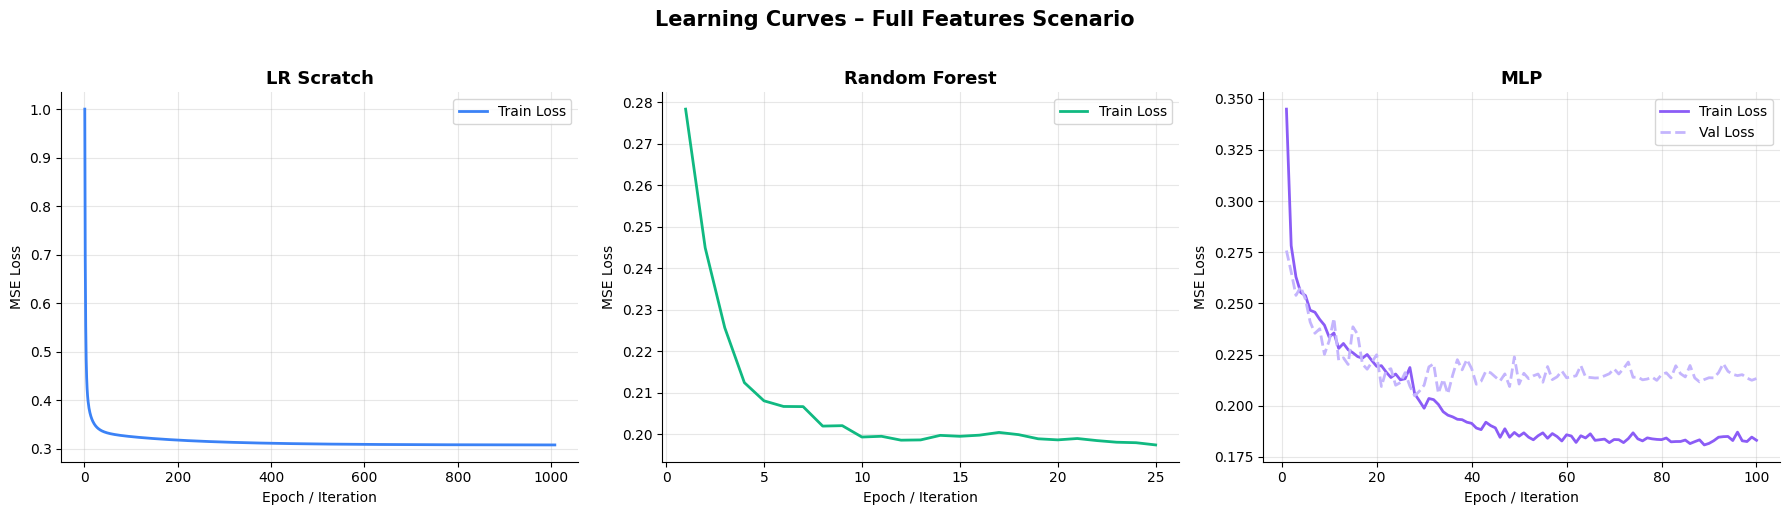

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Learning Curves – Full Features Scenario', fontsize=15, fontweight='bold', y=1.02)

model_names = ['LR Scratch', 'Random Forest', 'MLP']
colors = [('#3B82F6', '#93C5FD'), ('#10B981', '#6EE7B7'), ('#8B5CF6', '#C4B5FD')]

for ax, mname, (c_tr, c_val) in zip(axes, model_names, colors):
    tr_hist, val_hist = loss_store[('Full Features', mname)]
    epochs_x = range(1, len(tr_hist)+1)
    ax.plot(epochs_x, tr_hist, color=c_tr, lw=2, label='Train Loss')
    if val_hist:
        ax.plot(epochs_x, val_hist, color=c_val, lw=2, linestyle='--', label='Val Loss')
    ax.set_title(f'{mname}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch / Iteration')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 7. Metrics Comparison – Visualisation

Bar charts comparing MAE, RMSE, MAPE, and R² across all three models and scenarios.

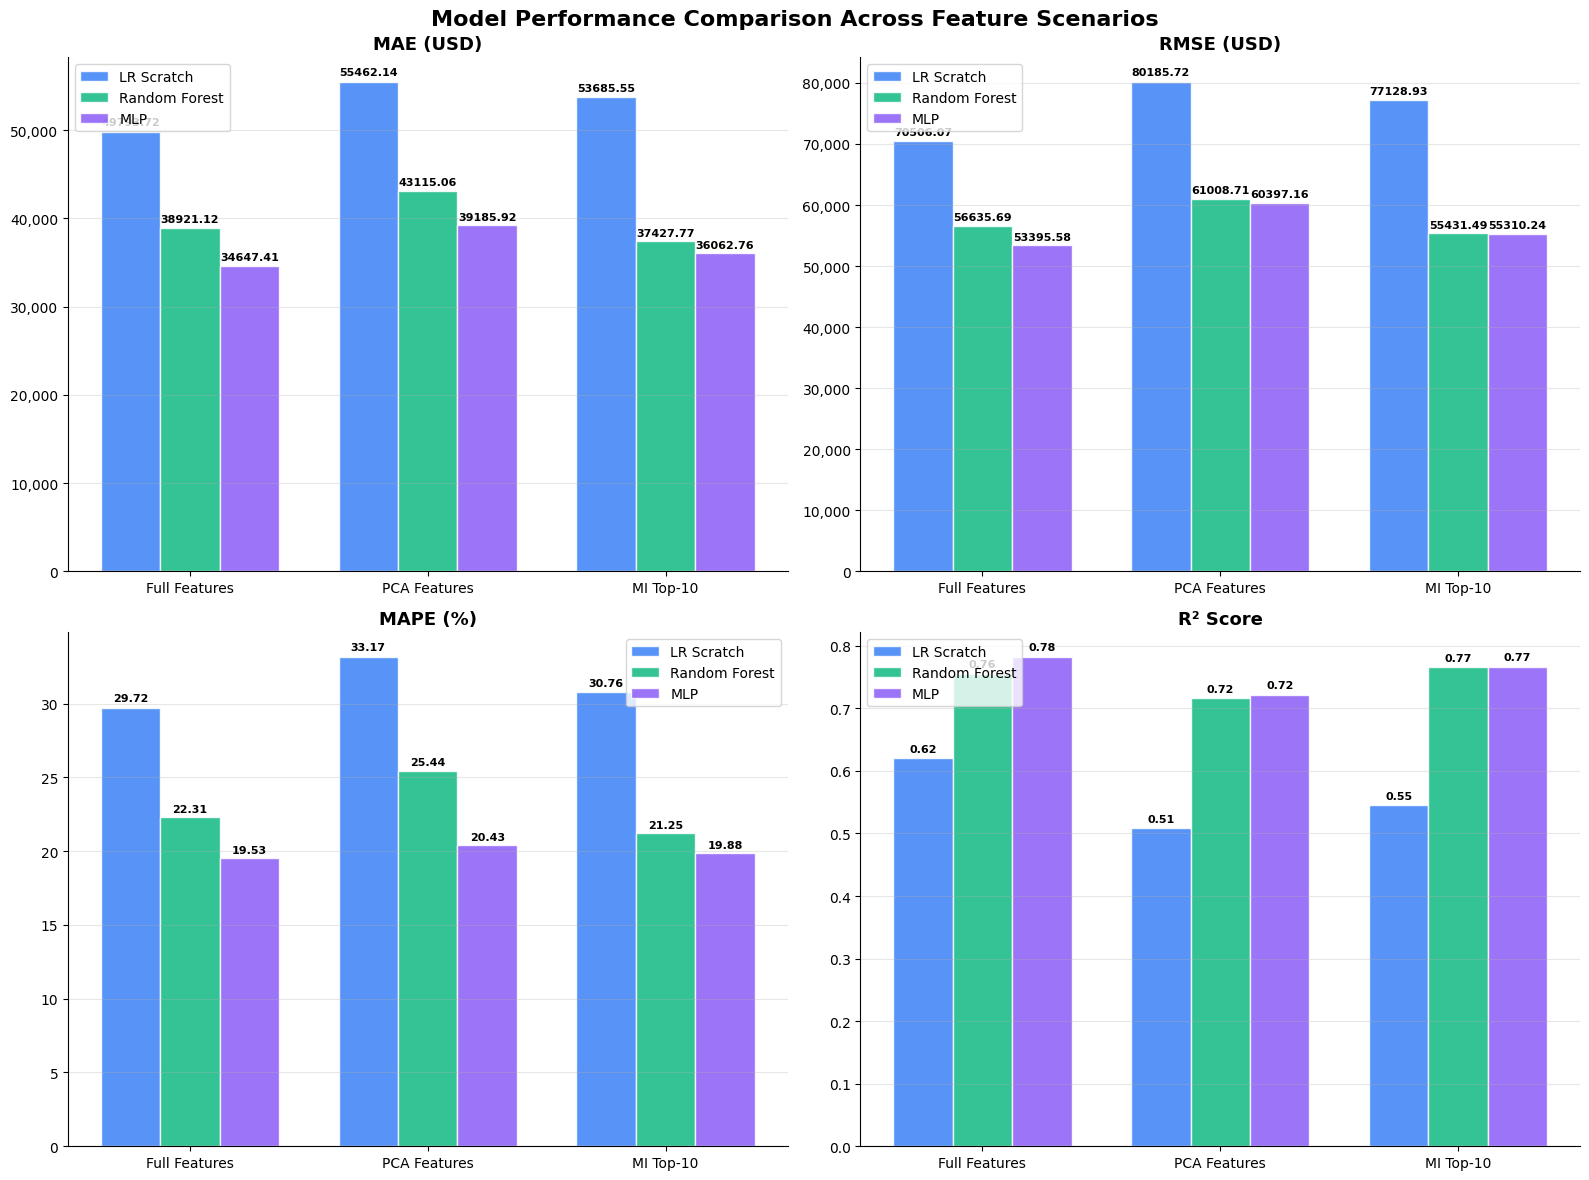

In [11]:
metrics_cols = ['MAE', 'RMSE', 'MAPE(%)', 'R2']
metric_labels = ['MAE (USD)', 'RMSE (USD)', 'MAPE (%)', 'R² Score']
model_order = ['LR Scratch', 'Random Forest', 'MLP']
sc_order = ['Full Features', 'PCA Features', 'MI Top-10']
bar_colors = ['#3B82F6', '#10B981', '#8B5CF6']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison Across Feature Scenarios', fontsize=16, fontweight='bold')

for idx, (metric, label) in enumerate(zip(metrics_cols, metric_labels)):
    ax = axes[idx // 2][idx % 2]
    x = np.arange(len(sc_order))
    width = 0.25
    for mi, (mname, color) in enumerate(zip(model_order, bar_colors)):
        vals = [df[(df['Scenario']==sc) & (df['Model']==mname)][metric].values[0]
                for sc in sc_order]
        bars = ax.bar(x + mi*width, vals, width, label=mname, color=color, alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(sc_order, fontsize=10)
    ax.legend(fontsize=10)
    
    # Format y-axis to display regular numbers (avoid 1e5 / scientific notation)
    if metric in ['MAE', 'RMSE']:
        ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
        
    ax.grid(True, axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 8. Prediction Scatter Plots (All Models × All Scenarios)

Scatter of predicted vs actual house prices. A perfect model would have all points on the red diagonal.

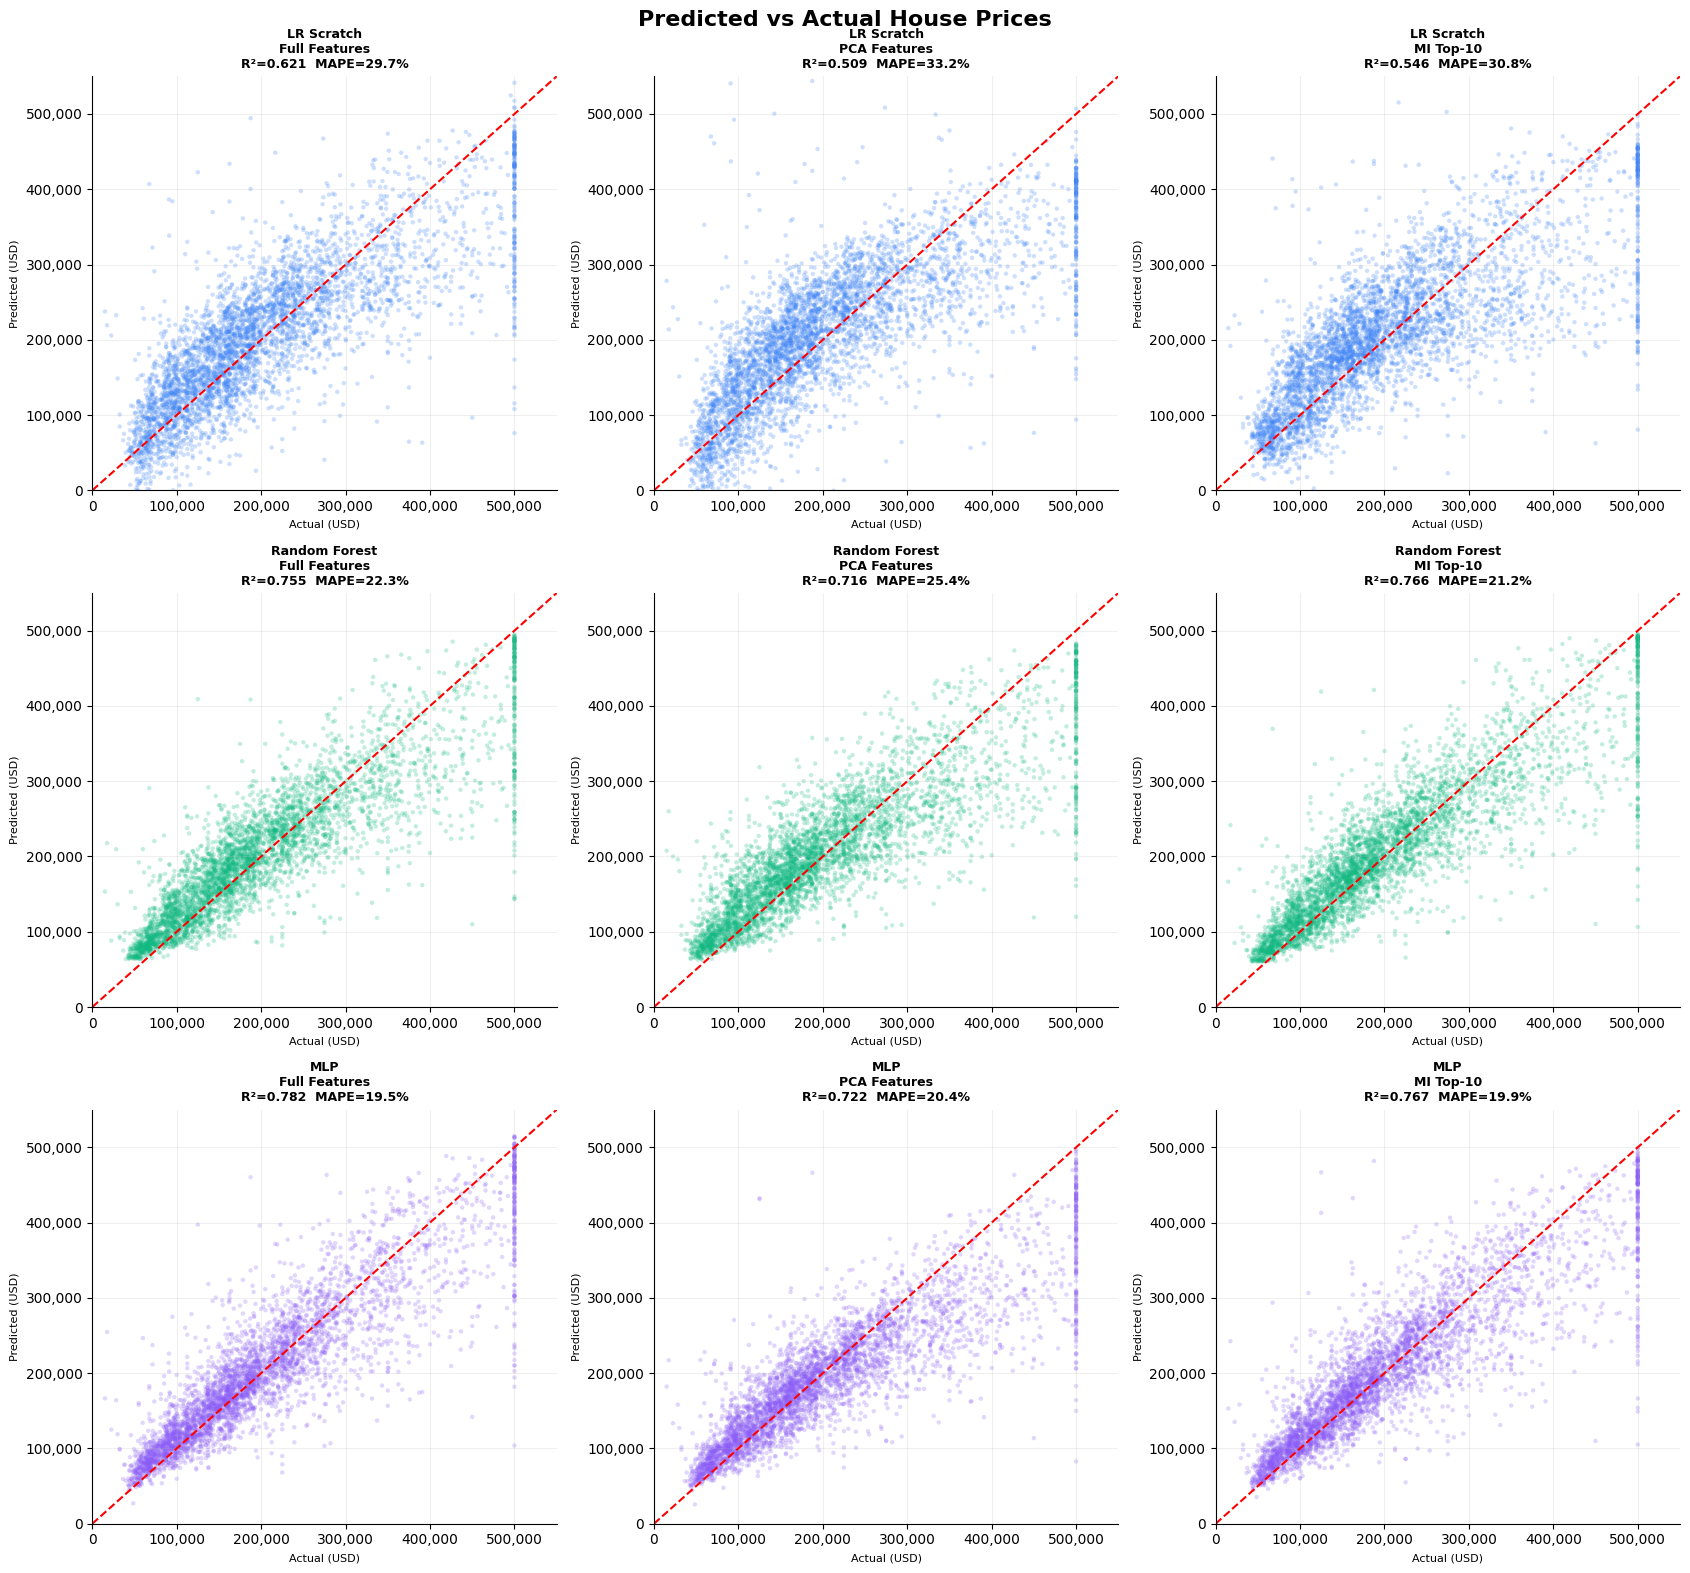

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(17, 16))
fig.suptitle('Predicted vs Actual House Prices', fontsize=16, fontweight='bold')

scatter_colors = {'LR Scratch': '#3B82F6', 'Random Forest': '#10B981', 'MLP': '#8B5CF6'}

for row, mname in enumerate(model_names):
    for col, sc_name in enumerate(sc_order):
        ax = axes[row][col]
        y_pred = pred_store[(sc_name, mname)]
        r2_val = df[(df['Scenario']==sc_name) & (df['Model']==mname)]['R2'].values[0]
        mape_val = df[(df['Scenario']==sc_name) & (df['Model']==mname)]['MAPE(%)'].values[0]

        ax.scatter(y_test, y_pred, alpha=0.25, s=10, color=scatter_colors[mname], edgecolors='none')
        
        # Limit to the realistic housing price range to make the plots wider and focused
        ax.set_xlim([0, 550000])
        ax.set_ylim([0, 550000])
        
        # Plot diagonal line
        ax.plot([0, 550000], [0, 550000], 'r--', lw=1.5)

        # Format ticks to regular numbers with commas
        ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
        ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

        ax.set_title(f'{mname}\n{sc_name}\nR²={r2_val:.3f}  MAPE={mape_val:.1f}%',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('Actual (USD)', fontsize=8)
        ax.set_ylabel('Predicted (USD)', fontsize=8)
        ax.grid(True, alpha=0.2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [13]:
# Tạo bản sao để định dạng hiển thị đẹp mắt
display_df = df.copy()

# Định dạng các cột số tiền mặt (USD) với dấu phẩy phân tách hàng nghìn
display_df['MAE'] = display_df['MAE'].map('{:,.0f}'.format)
display_df['RMSE'] = display_df['RMSE'].map('{:,.0f}'.format)

# Định dạng các tỷ lệ phần trăm và R2 làm tròn số thập phân
display_df['MAPE(%)'] = display_df['MAPE(%)'].map('{:.2f}'.format)
display_df['R2'] = display_df['R2'].map('{:.4f}'.format)

# Định dạng thời gian chạy (mili-giây)
display_df['Train_ms'] = display_df['Train_ms'].map('{:.0f}'.format)
display_df['Inf_ms'] = display_df['Inf_ms'].map('{:.1f}'.format)

# Đổi tên các cột hiển thị cho chuyên nghiệp
display_df.columns = [
    'Scenario', 
    'Model', 
    'MAE (USD)', 
    'RMSE (USD)', 
    'MAPE (%)', 
    'R² Score', 
    'Train (ms)', 
    'Inf (ms)'
]

print('\n--- Final Scenario Comparison Results Table ---')
print(display_df.to_string(index=False))


--- Final Scenario Comparison Results Table ---
     Scenario         Model MAE (USD) RMSE (USD) MAPE (%) R² Score Train (ms) Inf (ms)
Full Features    LR Scratch    49,794     70,506    29.72   0.6206        236      0.0
Full Features Random Forest    38,921     56,636    22.31   0.7552       8406    119.6
Full Features           MLP    34,647     53,396    19.53   0.7824      42003      1.0
 PCA Features    LR Scratch    55,462     80,186    33.17   0.5093        195      1.0
 PCA Features Random Forest    43,115     61,009    25.44   0.7160       7632    119.9
 PCA Features           MLP    39,186     60,397    20.43   0.7216      39733      1.0
    MI Top-10    LR Scratch    53,686     77,129    30.76   0.5460        129      0.0
    MI Top-10 Random Forest    37,428     55,431    21.25   0.7655       7050    126.3
    MI Top-10           MLP    36,063     55,310    19.88   0.7665      40531      1.0
